In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import roc_curve, auc
import pyhf

# Directories
csv_dir = Path("/home/paul/Msci/ntuples/cos_theta_csvs/")
plot_dir = Path("/home/paul/Msci/plots/sensitivity/cos_theta/")

# NuMI beam direction (for reference)
v_numi = np.array([0.462372, 0.0488541, 0.885339])

# POT and scaling factors
target_pot_run1 = 2.2e20

scalings_run1 = {
    "nu": 1.0 / 2.35e21,
    "dirt": 1.026 * 0.75 / 1.6e21,
    "beamoff": 0.98 * (6230439.0 / 9186361.390000)
}
theta_cut = 0.9

In [2]:
# Load signal files
signal_files = sorted(csv_dir.glob("run1_dt_ratio_0.6*_cos_theta.csv"))
signal_dfs = {}
for f in signal_files:
    name = f.stem.replace("_cos_theta", "")
    signal_dfs[name] = pd.read_csv(f)
    print(f"Loaded {name}: {len(signal_dfs[name])} events")

Loaded run1_dt_ratio_0.6_ma_0.01_pi0_sp: 7180 events
Loaded run1_dt_ratio_0.6_ma_0.02_eta_sp: 7335 events
Loaded run1_dt_ratio_0.6_ma_0.02_pi0_sp: 10252 events
Loaded run1_dt_ratio_0.6_ma_0.03_eta_sp: 6155 events
Loaded run1_dt_ratio_0.6_ma_0.03_pi0_sp: 7642 events
Loaded run1_dt_ratio_0.6_ma_0.04_eta_sp: 9885 events
Loaded run1_dt_ratio_0.6_ma_0.04_pi0_sp: 9764 events
Loaded run1_dt_ratio_0.6_ma_0.05_eta_sp: 9784 events
Loaded run1_dt_ratio_0.6_ma_0.05_pi0_sp: 7910 events
Loaded run1_dt_ratio_0.6_ma_0.06_eta_sp: 9294 events
Loaded run1_dt_ratio_0.6_ma_0.06_pi0_sp: 8504 events
Loaded run1_dt_ratio_0.6_ma_0.07_eta_sp: 6902 events
Loaded run1_dt_ratio_0.6_ma_0.07_pi0_sp: 7561 events
Loaded run1_dt_ratio_0.6_ma_0.08_eta_sp: 7633 events
Loaded run1_dt_ratio_0.6_ma_0.08_pi0_sp: 7735 events
Loaded run1_dt_ratio_0.6_ma_0.09_eta_sp: 7852 events
Loaded run1_dt_ratio_0.6_ma_0.09_pi0_sp: 6487 events
Loaded run1_dt_ratio_0.6_ma_0.1_eta_sp: 16759 events
Loaded run1_dt_ratio_0.6_ma_0.2_eta_sp: 12555

In [3]:
# Load backgrounds
df_nu = pd.read_csv(csv_dir / "run1_nu_overlay_cos_theta.csv")
df_dirt = pd.read_csv(csv_dir / "run1_dirt_cos_theta.csv")
df_offbeam = pd.read_csv(csv_dir / "run1_offbeam_cos_theta.csv")

print(f"Nu overlay: {len(df_nu)} events")
print(f"Dirt: {len(df_dirt)} events")
print(f"Offbeam: {len(df_offbeam)} events")

# Load NC backgrounds (for comparison)
df_ncpi0 = pd.read_csv(csv_dir / "NCPi0_cos_theta.csv")
df_nceta = pd.read_csv(csv_dir / "NCeta_cos_theta.csv")

print(f"NCPi0: {len(df_ncpi0)} events")
print(f"NCeta: {len(df_nceta)} events")

Nu overlay: 131891 events
Dirt: 24016 events
Offbeam: 38792 events
NCPi0: 26077 events
NCeta: 28767 events


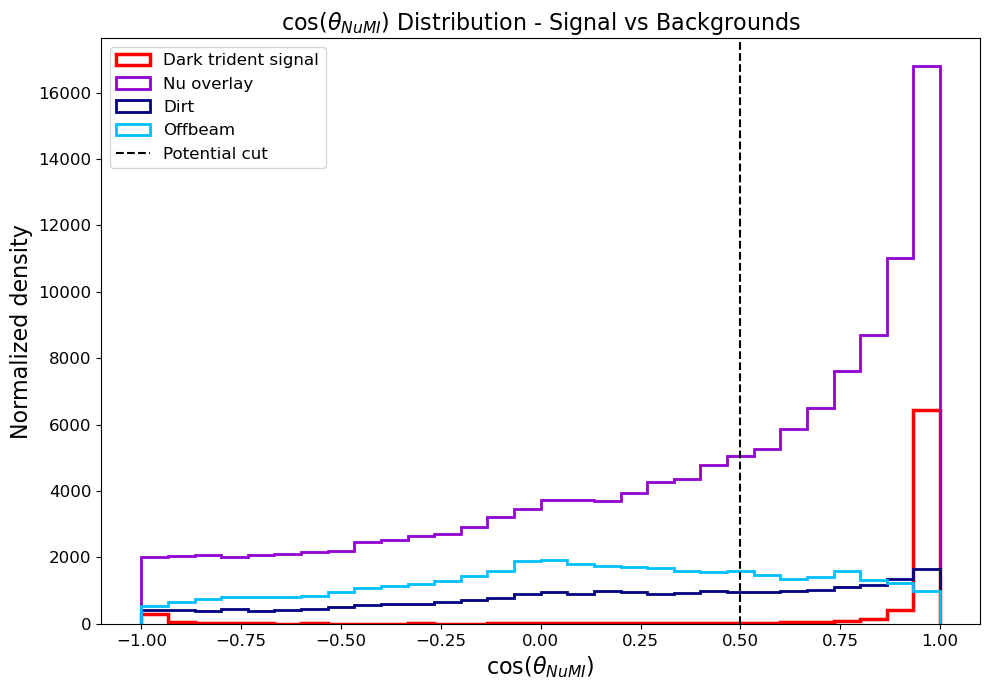

In [4]:
fig, ax = plt.subplots(figsize=(10, 7))

bins = np.linspace(-1, 1, 31)

df_sig = signal_dfs["run1_dt_ratio_0.6_ma_0.05_pi0_sp"]

ax.hist(df_sig['cos_theta'], bins=bins, density=False, histtype='step', 
        linewidth=2.5, color='red', label='Dark trident signal')
ax.hist(df_nu['cos_theta'], bins=bins, density=False, histtype='step', 
        linewidth=2, color='darkviolet', label='Nu overlay')
ax.hist(df_dirt['cos_theta'], bins=bins, density=False, histtype='step', 
        linewidth=2, color='navy', label='Dirt')
ax.hist(df_offbeam['cos_theta'], bins=bins, density=False, histtype='step', 
        linewidth=2, color='deepskyblue', label='Offbeam')

ax.axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Potential cut')

ax.set_xlabel(r'cos($\theta_{NuMI}$)', fontsize=16)
ax.set_ylabel('Normalized density', fontsize=16)
ax.set_title(r'cos($\theta_{NuMI}$) Distribution - Signal vs Backgrounds', fontsize=16)
ax.legend(fontsize=12)
ax.tick_params(labelsize=12)

plt.tight_layout()
plt.savefig(plot_dir / "cos_theta_signal_vs_background.png", dpi=150)
plt.show()

In [5]:
ref_signal_key = 'run1_dt_ratio_0.6_ma_0.05_pi0_sp'
df_signal_ref = signal_dfs[ref_signal_key].copy()

# Combine backgrounds
df_bkg_combined = pd.concat([df_nu, df_dirt, df_offbeam], ignore_index=True)

print(f"Reference signal events: {len(df_signal_ref)}")
print(f"Combined background events: {len(df_bkg_combined)}")

Reference signal events: 7910
Combined background events: 194699


In [6]:
signal_cos = df_signal_ref['cos_theta'].values
bkg_cos = df_bkg_combined['cos_theta'].values

y_true = np.concatenate([np.ones(len(signal_cos)), np.zeros(len(bkg_cos))])
y_score = np.concatenate([signal_cos, bkg_cos])

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

print(f"AUC for cos(θ): {roc_auc:.4f}")

AUC for cos(θ): 0.8926


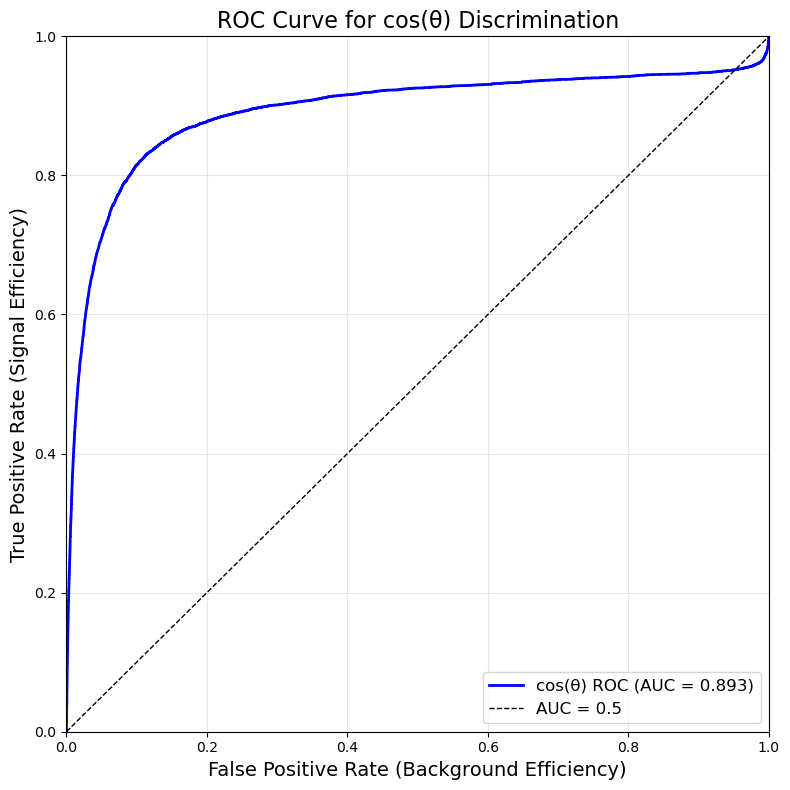

In [7]:
# Plot ROC curve
fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(fpr, tpr, 'b-', lw=2, label=f'cos(θ) ROC (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='AUC = 0.5')

ax.set_xlabel('False Positive Rate (Background Efficiency)', fontsize=14)
ax.set_ylabel('True Positive Rate (Signal Efficiency)', fontsize=14)
ax.set_title('ROC Curve for cos(θ) Discrimination', fontsize=16)
ax.legend(loc='lower right', fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig(plot_dir / 'costheta_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
# Scan cut values
cut_values = np.linspace(-0.5, 1, 50)
results = []

for cut in cut_values:
    s = np.sum(df_signal_ref['cos_theta'] > cut)

    b_nu = np.sum(df_nu['cos_theta'] > cut)
    b_dirt = np.sum(df_dirt['cos_theta'] > cut)
    b_offbeam = np.sum(df_offbeam['cos_theta'] > cut)
    b = b_nu + b_dirt + b_offbeam
    
    if b > 0:
        significance = s / np.sqrt(b)
    else:
        significance = 0 # Avoid divison by 0
    
    sig_eff = s / len(df_signal_ref)
    bkg_eff = b / (len(df_nu) + len(df_dirt) + len(df_offbeam))
    
    results.append({
        'cut': cut,
        's': s,
        'b': b,
        'significance': significance,
        'sig_eff': sig_eff,
        'bkg_eff': bkg_eff
    })

df_opt = pd.DataFrame(results)

# Find optimal cut
best_idx = df_opt['significance'].idxmax()
best_cut = df_opt.loc[best_idx, 'cut']
best_signif = df_opt.loc[best_idx, 'significance']

print(f"Optimal cut: cos(θ) > {best_cut:.3f}")
print(f"Best s/√b: {best_signif:.3f}")
print(f"Signal efficiency at optimal: {df_opt.loc[best_idx, 'sig_eff']:.1%}")
print(f"Background efficiency at optimal: {df_opt.loc[best_idx, 'bkg_eff']:.1%}")

Optimal cut: cos(θ) > 0.969
Best s/√b: 56.024
Signal efficiency at optimal: 72.1%
Background efficiency at optimal: 5.3%


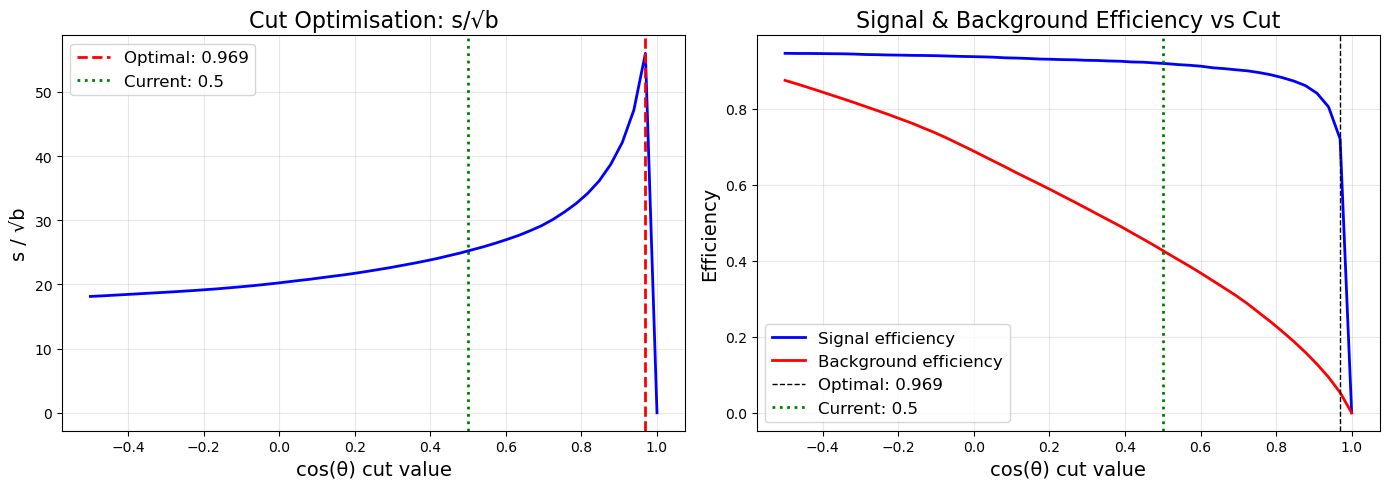

cos(θ) > -0.01: s/√b = 20.179, sig_eff = 93.7%, bkg_eff = 69.3%
cos(θ) > 0.51: s/√b = 25.389, sig_eff = 91.9%, bkg_eff = 42.1%
cos(θ) > 0.97: s/√b = 56.024, sig_eff = 72.1%, bkg_eff = 5.3%
cos(θ) > 0.79: s/√b = 32.603, sig_eff = 89.0%, bkg_eff = 23.9%
cos(θ) > 0.91: s/√b = 42.132, sig_eff = 84.1%, bkg_eff = 12.8%


In [9]:
# Plot s/sqrt(b) vs cut value
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: s/sqrt(b) vs cut
ax1.plot(df_opt['cut'], df_opt['significance'], 'b-', lw=2)
ax1.axvline(best_cut, color='r', linestyle='--', lw=2, label=f'Optimal: {best_cut:.3f}')
ax1.axvline(0.5, color='g', linestyle=':', lw=2, label='Current: 0.5')
ax1.set_xlabel('cos(θ) cut value', fontsize=14)
ax1.set_ylabel('s / √b', fontsize=14)
ax1.set_title('Cut Optimisation: s/√b', fontsize=16)
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)

# Right plot: signal vs background efficiency
ax2.plot(df_opt['cut'], df_opt['sig_eff'], 'b-', lw=2, label='Signal efficiency')
ax2.plot(df_opt['cut'], df_opt['bkg_eff'], 'r-', lw=2, label='Background efficiency')
ax2.axvline(best_cut, color='k', linestyle='--', lw=1, label=f'Optimal: {best_cut:.3f}')
ax2.axvline(0.5, color='g', linestyle=':', lw=2, label='Current: 0.5')
ax2.set_xlabel('cos(θ) cut value', fontsize=14)
ax2.set_ylabel('Efficiency', fontsize=14)
ax2.set_title('Signal & Background Efficiency vs Cut', fontsize=16)
ax2.legend(fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(plot_dir / 'costheta_cut_optimisation.png', dpi=300, bbox_inches='tight')
plt.show()

# Print comparison table
for cut_val in [0.0, 0.5, best_cut, 0.8, 0.9]:
    row = df_opt.iloc[(df_opt['cut'] - cut_val).abs().argmin()]
    print(f"cos(θ) > {row['cut']:.2f}: s/√b = {row['significance']:.3f}, "
          f"sig_eff = {row['sig_eff']:.1%}, bkg_eff = {row['bkg_eff']:.1%}")

In [10]:
# Match CNN parameters exactly
nominal_eps = 1e-3
scaling_factor = 0.05
fraction_outside = 1.1

if theta_cut >= 0.5:
    cosbins = np.array([theta_cut, 1.0])  
else:
    cosbins = np.array([theta_cut, 0.5, 1.0])  # Two bins

print(f"cos(θ) bins: {cosbins}")
print(f"Number of bins: {len(cosbins) - 1}")

# Check collumns...
print("df_nu columns:", df_nu.columns.tolist())
print("df_dirt columns:", df_dirt.columns.tolist())
print("df_offbeam columns:", df_offbeam.columns.tolist())

cos(θ) bins: [0.9 1. ]
Number of bins: 1
df_nu columns: ['run', 'subrun', 'event', 'cos_theta', 'weight_spline', 'weight_tune', 'weight']
df_dirt columns: ['run', 'subrun', 'event', 'cos_theta', 'weight_spline', 'weight_tune', 'weight']
df_offbeam columns: ['run', 'subrun', 'event', 'cos_theta', 'weight_spline', 'weight_tune', 'weight']


In [11]:
nu_scaling = target_pot_run1 * scalings_run1['nu']
dirt_scaling = target_pot_run1 * scalings_run1['dirt']
offbeam_scaling = scalings_run1['beamoff']

df_nu_sr = df_nu[df_nu['cos_theta'] > theta_cut].copy()
df_dirt_sr = df_dirt[df_dirt['cos_theta'] > theta_cut].copy()
df_offbeam_sr = df_offbeam[df_offbeam['cos_theta'] > theta_cut].copy()

# Histogram backgrounds
hist_nu, _ = np.histogram(df_nu_sr['cos_theta'], bins=cosbins, weights=df_nu_sr['weight'])
hist_dirt, _ = np.histogram(df_dirt_sr['cos_theta'], bins=cosbins, weights=df_dirt_sr['weight'])
hist_offbeam, _ = np.histogram(df_offbeam_sr['cos_theta'], bins=cosbins)

# Apply POT scaling
hist_nu = hist_nu * nu_scaling
hist_dirt = hist_dirt * dirt_scaling
hist_offbeam = hist_offbeam * offbeam_scaling

# Total background
hist_bkg = hist_nu + hist_dirt + hist_offbeam
nbkg = hist_bkg.tolist()

print(f"  Nu:      {hist_nu}")
print(f"  Dirt:    {hist_dirt}")
print(f"  Offbeam: {hist_offbeam}")
print(f"  Total:   {hist_bkg}")

  Nu:      [2129.6]
  Dirt:    [244.09501875]
  Offbeam: [1035.54422463]
  Total:   [3409.23924338]


In [12]:
correction_dica = {
    'pi0': {0.01: 11.198, 0.02: 11.145, 0.03: 10.861, 0.04: 11.543, 0.05: 10.671,
            0.06: 10.098, 0.07: 8.741, 0.08: 10.282, 0.09: 9.333},
    'eta': {0.02: 10.555, 0.03: 9.759, 0.04: 7.934, 0.05: 9.387, 0.06: 9.863,
            0.07: 10.301, 0.08: 9.141, 0.09: 7.273, 0.1: 7.228, 0.2: 7.597,
            0.3: 5.219, 0.4: 4.498}
}

# Meson scalings
meson_scalings = {'pi0': 11.7, 'eta': 7.2}

total_pot = {
    'run1_dt_ratio_0.6_ma_0.01_pi0': 3.583299e20,
    'run1_dt_ratio_0.6_ma_0.02_eta': 1.971339e22,
    'run1_dt_ratio_0.6_ma_0.02_pi0': 3.785739e21,
    'run1_dt_ratio_0.6_ma_0.03_eta': 6.018737e22,
    'run1_dt_ratio_0.6_ma_0.03_pi0': 1.403744e22,
    'run1_dt_ratio_0.6_ma_0.04_eta': 2.797252e23,
    'run1_dt_ratio_0.6_ma_0.04_pi0': 6.144923e22,
    'run1_dt_ratio_0.6_ma_0.05_eta': 6.491310e23,
    'run1_dt_ratio_0.6_ma_0.05_pi0': 1.594137e23,
    'run1_dt_ratio_0.6_ma_0.06_eta': 1.333156e24,
    'run1_dt_ratio_0.6_ma_0.06_pi0': 5.428614e23,
    'run1_dt_ratio_0.6_ma_0.07_eta': 1.726805e24,
    'run1_dt_ratio_0.6_ma_0.07_pi0': 2.122624e24,
    'run1_dt_ratio_0.6_ma_0.08_eta': 3.721201e24,
    'run1_dt_ratio_0.6_ma_0.08_pi0': 9.137349e24,
    'run1_dt_ratio_0.6_ma_0.09_eta': 6.937703e24,
    'run1_dt_ratio_0.6_ma_0.09_pi0': 4.752829e25,
    'run1_dt_ratio_0.6_ma_0.1_eta': 2.632356e25,
    'run1_dt_ratio_0.6_ma_0.2_eta': 2.642929e27,
    'run1_dt_ratio_0.6_ma_0.3_eta': 4.548050e29,
    'run1_dt_ratio_0.6_ma_0.4_eta': 2.856632e32,
}

xsec_uncert_a = {
    'pi0': {0.01: 1.16, 0.02: 2.27, 0.03: 3.48, 0.04: 4.48, 0.05: 5.50,
            0.06: 5.92, 0.07: 7.17, 0.08: 8.55, 0.09: 8.97},
    'eta': {0.02: 2.09, 0.03: 3.50, 0.04: 4.33, 0.05: 6.07, 0.06: 6.26,
            0.07: 7.45, 0.08: 8.72, 0.09: 8.99, 0.1: 9.63, 0.2: 18.95,
            0.3: 22.04, 0.4: 30.34}
}

def get_signal_scaling(mass, dmode):
    """Calculate signal scaling matching CNN method"""
    # FIX: Use underscore format to match total_pot keys
    key = f'run1_dt_ratio_0.6_ma_{mass}_{dmode}'
    pot = total_pot[key]
    scale = meson_scalings[dmode] * target_pot_run1 * correction_dica[dmode][mass] / pot
    return scale

def load_signal_for_mass(mass):
    """Load and histogram signal for given mass"""
    hist_signal = np.zeros(len(cosbins) - 1)
    
    # Determine decay modes
    if mass <= 0.01:
        decay_modes = ['pi0']
    elif float(mass) >= 0.1:
        decay_modes = ['eta']
    else:
        decay_modes = ['pi0', 'eta']
    
    for dmode in decay_modes:
        # FIX: Use underscore format with _sp suffix
        key = f'run1_dt_ratio_0.6_ma_{mass}_{dmode}_sp'
        if key not in signal_dfs:
            print(f"  Warning: {key} not found")
            continue
        
        df = signal_dfs[key]
        
        # Filter to signal region 
        df_sr = df[df['cos_theta'] > theta_cut].copy()
        
        # Get scaling
        scale = get_signal_scaling(mass, dmode)
        
        # Histogram
        hist, _ = np.histogram(df_sr['cos_theta'], bins=cosbins)
        hist_signal += hist * scale
    
    return hist_signal

In [13]:
results = []
masses = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.2, 0.3, 0.4]

for mass in masses:
    print(f"\n{'='*50}")
    print(f"Mass {mass} GeV")
    print(f"{'='*50}")
    
    # Load signal
    hist_signal = load_signal_for_mass(mass)
    hist_signal = np.maximum(hist_signal, 0.01)  # Floor value
    
    if np.sum(hist_signal) == 0:
        print("  No signal, skipping")
        continue
    
    # Calculate xsec uncertainty
    xsec_uncert_sq = 0
    if mass <= 0.01:
        decay_modes = ['pi0']
    elif float(mass) >= 0.1:
        decay_modes = ['eta']
    else:
        decay_modes = ['pi0', 'eta']
    
    for dmode in decay_modes:
        if dmode in xsec_uncert_a and mass in xsec_uncert_a[dmode]:
            xsec_uncert_sq += xsec_uncert_a[dmode][mass]**2
    
    xsec_uncert = np.sqrt(xsec_uncert_sq) / 100
    print(f"  Cross-section uncertainty: {xsec_uncert*100:.1f}%")
    
    # Signal scaling (match CNN)
    total_sig = np.sum(hist_signal)
    total_bkg = np.sum(nbkg)
    factor = scaling_factor * total_bkg / total_sig
    print(f"  Scaling factor: {factor:.6e}")
    
    nsig = hist_signal.tolist()
    nsig_scaled = [s * factor * fraction_outside for s in nsig]
    
    print(f"  Signal: {sum(nsig_scaled):.1f} events")
    print(f"  Background: {sum(nbkg):.1f} events")
    
    # Build pyhf model (match CNN systematics)
    spec = {
        "channels": [{
            "name": "costheta",
            "samples": [
                {
                    "name": "signal",
                    "data": nsig_scaled,
                    "modifiers": [
                        {"name": "mu", "type": "normfactor", "data": None},
                        {"name": "potuncert", "type": "normsys", 
                         "data": {"hi": 1.02, "lo": 0.98}},
                        {"name": "fluxuncert", "type": "normsys",
                         "data": {"hi": 1.22, "lo": 0.78}},
                        {"name": "detuncert", "type": "normsys",
                         "data": {"hi": 1.18, "lo": 0.82}},
                        {"name": "xsecuncert", "type": "normsys",
                         "data": {"hi": 1+xsec_uncert, "lo": 1-xsec_uncert}}
                    ]
                },
                {
                    "name": "background",
                    "data": nbkg,
                    "modifiers": [
                        {"name": "potuncert", "type": "normsys",
                         "data": {"hi": 1.02, "lo": 0.98}}
                    ]
                }
            ]
        }]
    }
    
    model = pyhf.Model(spec)
    
    # FIX: Create proper data with auxiliary data
    data = nbkg + model.config.auxdata  # This adds the auxiliary constraint terms
    
    # Calculate limits
    poi_values = np.linspace(0., 10., 100)
    
    try:
        # Use the full data (main + aux)
        obs_limit, exp_limits = pyhf.infer.intervals.upper_limits.upper_limit(
            data, model, poi_values, level=0.1, return_results=False
        )
        
        # Convert to epsilon squared (match CNN formula)
        obs_epsilon = (nominal_eps**2) * np.sqrt(obs_limit * factor)
        exp_epsilon = (nominal_eps**2) * np.sqrt(exp_limits[2] * factor)
        
        exp_minus2 = (nominal_eps**2) * np.sqrt(exp_limits[0] * factor)
        exp_minus1 = (nominal_eps**2) * np.sqrt(exp_limits[1] * factor)
        exp_median = (nominal_eps**2) * np.sqrt(exp_limits[2] * factor)
        exp_plus1 = (nominal_eps**2) * np.sqrt(exp_limits[3] * factor)
        exp_plus2 = (nominal_eps**2) * np.sqrt(exp_limits[4] * factor)
        
        results.append({
            'mass': float(mass),
            'mu_obs': obs_limit,
            'mu_exp': exp_limits[2],
            'mu_exp_minus2': exp_limits[0],
            'mu_exp_minus1': exp_limits[1],
            'mu_exp_plus1': exp_limits[3],
            'mu_exp_plus2': exp_limits[4],
            'epsilon_squared_obs': obs_epsilon,
            'epsilon_squared_exp': exp_median,
            'epsilon_squared_exp_minus2': exp_minus2,
            'epsilon_squared_exp_minus1': exp_minus1,
            'epsilon_squared_exp_plus1': exp_plus1,
            'epsilon_squared_exp_plus2': exp_plus2,
            'factor': factor
        })
        
        print(f"obs={obs_limit:.4f}, exp={exp_limits[2]:.4f}")
        print(f"bands: -2σ={exp_limits[0]:.3f}, -1σ={exp_limits[1]:.3f}, +1σ={exp_limits[3]:.3f}, +2σ={exp_limits[4]:.3f}")
        print(f"ε²_obs={obs_epsilon:.2e}, ε²_exp={exp_median:.2e}")
        
    except Exception as e:
        print(f"Error: {e}")

# Save results to CSV (like CNN analysis)
if len(results) > 0: 
    df_costheta = pd.DataFrame(results)
    df_costheta = df_costheta.sort_values('mass')
    
    # Save it
    df_costheta.to_csv(plot_dir / f'costheta_sensitivity_results_cut_{theta_cut}.csv', index=False)
    print(f"\n{'='*50}")
    print(f"Saved {len(df_costheta)} mass points to costheta_sensitivity_results.csv")
    print(f"{'='*50}")
    print(df_costheta)
else:
    print("\n✗ No results to save - all masses failed")



Mass 0.01 GeV
  Cross-section uncertainty: 1.2%
  Scaling factor: 3.475724e-04
  Signal: 187.5 events
  Background: 3409.2 events
obs=0.9081, exp=0.9081
bands: -2σ=0.423, -1σ=0.595, +1σ=1.489, +2σ=2.465
ε²_obs=1.78e-08, ε²_exp=1.78e-08

Mass 0.02 GeV
  Cross-section uncertainty: 3.1%
  Scaling factor: 2.361515e-03
  Signal: 187.5 events
  Background: 3409.2 events
obs=0.9088, exp=0.9088
bands: -2σ=0.423, -1σ=0.595, +1σ=1.491, +2σ=2.471
ε²_obs=4.63e-08, ε²_exp=4.63e-08

Mass 0.03 GeV
  Cross-section uncertainty: 4.9%
  Scaling factor: 1.199601e-02
  Signal: 187.5 events
  Background: 3409.2 events
obs=0.9104, exp=0.9104
bands: -2σ=0.424, -1σ=0.596, +1σ=1.495, +2σ=2.483
ε²_obs=1.05e-07, ε²_exp=1.05e-07

Mass 0.04 GeV
  Cross-section uncertainty: 6.2%
  Scaling factor: 3.900318e-02
  Signal: 187.5 events
  Background: 3409.2 events
obs=0.9121, exp=0.9121
bands: -2σ=0.424, -1σ=0.596, +1σ=1.499, +2σ=2.495
ε²_obs=1.89e-07, ε²_exp=1.89e-07

Mass 0.05 GeV
  Cross-section uncertainty: 8.2%
  S

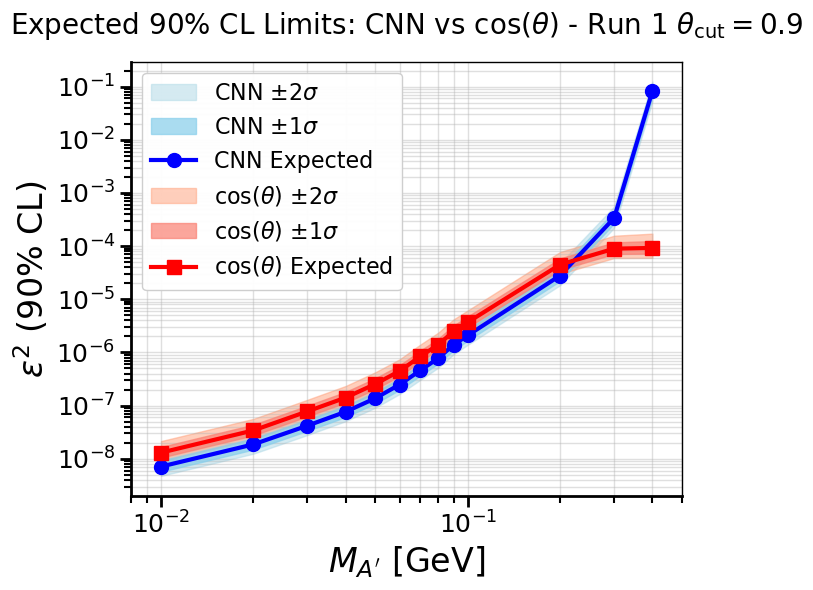


=== Sensitivity Ratio (cos(θ) / CNN) ===
    mass  epsilon_squared_exp_cnn  epsilon_squared_exp_costheta  \
0   0.01             7.120166e-09                  1.301862e-08   
1   0.02             1.861759e-08                  3.408679e-08   
2   0.03             4.189360e-08                  7.774936e-08   
3   0.04             7.644734e-08                  1.412068e-07   
4   0.05             1.377810e-07                  2.553597e-07   
5   0.06             2.487135e-07                  4.476269e-07   
6   0.07             4.582501e-07                  8.389963e-07   
7   0.08             7.732911e-07                  1.392364e-06   
8   0.09             1.396008e-06                  2.497403e-06   
9   0.10             2.094118e-06                  3.700364e-06   
10  0.20             2.795136e-05                  4.495468e-05   
11  0.30             3.376900e-04                  8.953112e-05   
12  0.40             8.290229e-02                  9.252761e-05   

    sensitivity_rat

In [14]:
# Load CNN results
df_cnn = pd.read_csv(plot_dir / 'sensitivity_results_run1only.csv')

# Load cos(θ) results
df_costheta = pd.read_csv(plot_dir / 'costheta_sensitivity_results.csv')

# Plot comparison with Brazil bands
fig, ax = plt.subplots(figsize=(7, 6))  # bigger canvas

# CNN bands and line
masses_cnn = df_cnn['mass'].values
exp_cnn = df_cnn['epsilon_squared_exp'].values
exp_m2_cnn = df_cnn['epsilon_squared_exp_minus2'].values
exp_m1_cnn = df_cnn['epsilon_squared_exp_minus1'].values
exp_p1_cnn = df_cnn['epsilon_squared_exp_plus1'].values
exp_p2_cnn = df_cnn['epsilon_squared_exp_plus2'].values

ax.fill_between(masses_cnn, exp_m2_cnn, exp_p2_cnn, 
                color='lightblue', alpha=0.5, label=r'CNN $\pm 2\sigma$', zorder=1)
ax.fill_between(masses_cnn, exp_m1_cnn, exp_p1_cnn, 
                color='skyblue', alpha=0.7, label=r'CNN $\pm 1\sigma$', zorder=2)
ax.plot(masses_cnn, exp_cnn, 'b-o', lw=3, markersize=10, label='CNN Expected', zorder=4)

masses_cos = df_costheta['mass'].values
exp_cos = df_costheta['epsilon_squared_exp'].values
exp_m2_cos = df_costheta['epsilon_squared_exp_minus2'].values
exp_m1_cos = df_costheta['epsilon_squared_exp_minus1'].values
exp_p1_cos = df_costheta['epsilon_squared_exp_plus1'].values
exp_p2_cos = df_costheta['epsilon_squared_exp_plus2'].values

ax.fill_between(masses_cos, exp_m2_cos, exp_p2_cos, 
                color='lightsalmon', alpha=0.5, label=r'cos($\theta$) $\pm 2\sigma$', zorder=1)
ax.fill_between(masses_cos, exp_m1_cos, exp_p1_cos, 
                color='salmon', alpha=0.7, label=r'cos($\theta$) $\pm 1\sigma$', zorder=2)
ax.plot(masses_cos, exp_cos, 'r-s', lw=3, markersize=10, label=r'cos($\theta$) Expected', zorder=4)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$M_{A^\prime}$ [GeV]', fontsize=24)
ax.set_ylabel(r'$\varepsilon^2$ (90% CL)', fontsize=24)
ax.set_title(rf'Expected 90% CL Limits: CNN vs cos($\theta$) - Run 1 $\theta_\mathrm{{cut}} = {theta_cut}$', 
             fontsize=20,pad=20)
ax.legend(fontsize=16, loc='upper left', framealpha=0.95, ncol=1)
ax.grid(True, alpha=0.4, which='both', linewidth=1)
ax.set_xlim(0.008, 0.5)

# Bigger tick labels and spines
ax.tick_params(axis='both', which='major', labelsize=18, length=8, width=2)
ax.tick_params(axis='both', which='minor', length=5, width=1.5)
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_linewidth(1)
ax.spines['right'].set_linewidth(1)

plt.tight_layout()
plt.savefig(plot_dir / 'cnn_vs_costheta_expected_brazil.png', dpi=300, bbox_inches='tight')
plt.savefig(plot_dir / 'cnn_vs_costheta_expected_brazil.pdf', bbox_inches='tight')
plt.show()

# Calculate sensitivity ratio (unchanged)
df_comparison = df_cnn.merge(df_costheta, on='mass', suffixes=('_cnn', '_costheta'))
df_comparison['sensitivity_ratio'] = df_comparison['epsilon_squared_exp_costheta'] / df_comparison['epsilon_squared_exp_cnn']

print("\n" + "="*60)
print("=== Sensitivity Ratio (cos(θ) / CNN) ===")
print("="*60)
print(df_comparison[['mass', 'epsilon_squared_exp_cnn', 'epsilon_squared_exp_costheta', 'sensitivity_ratio']])
print(f"\nMean ratio: {df_comparison['sensitivity_ratio'].mean():.2f}")
print("(Ratio > 1 means CNN gives stronger limits)")


File for cut -1.0 not found - skipping
File for cut 0.0 not found - skipping
Loaded cut 0.5: 13 mass points
Loaded cut 0.7: 13 mass points
Loaded cut 0.9: 13 mass points
Loaded cut 0.969: 13 mass points


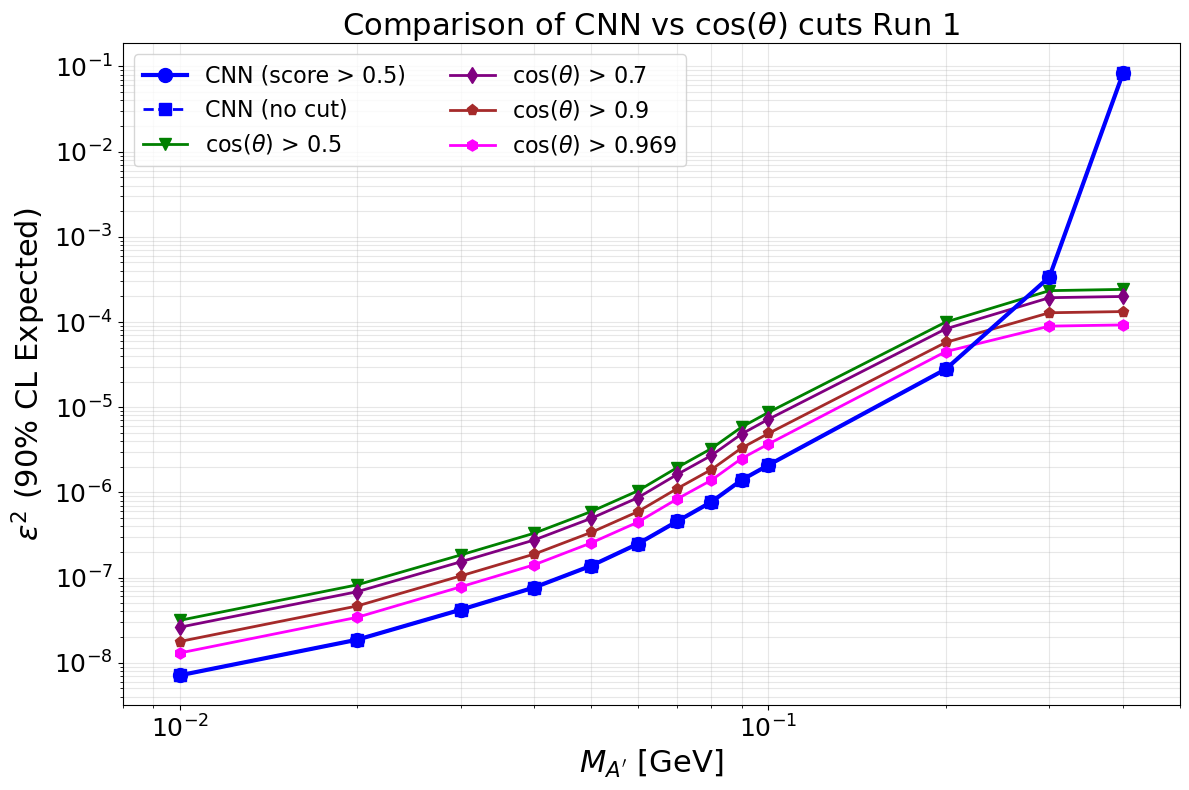

In [25]:
# Compare CNN (cut and no cut) vs multiple cos(theta) cuts
fig, ax = plt.subplots(figsize=(12, 8))
# Load CNN results
df_cnn_cut = pd.read_csv('/home/paul/Msci/plots/sensitivity/cos_theta/sensitivity_results_run1only.csv')
df_cnn_nocut = pd.read_csv('/home/paul/Msci/plots/sensitivity/cos_theta/sensitivity_results_run1only_nocut.csv')
# Plot CNN
ax.plot(df_cnn_cut['mass'], df_cnn_cut['epsilon_squared_exp'], 'b-o', lw=3, markersize=10, 
        label='CNN (score > 0.5)', zorder=10)
ax.plot(df_cnn_nocut['mass'], df_cnn_nocut['epsilon_squared_exp'], 'b--s', lw=2, markersize=8, 
        label='CNN (no cut)', zorder=9)
# cos(theta) cuts to plot
cuts_to_plot = [-1., 0., 0.5, 0.7, 0.9, 0.969]
colors = ['red', 'orange', 'green', 'purple', 'brown', 'magenta']
markers = ['s', '^', 'v', 'd', 'p', 'h']
for cut_val, color, marker in zip(cuts_to_plot, colors, markers):
    try:
        df_cut = pd.read_csv(plot_dir / f'costheta_sensitivity_results_cut_{cut_val}.csv')
        ax.plot(df_cut['mass'], df_cut['epsilon_squared_exp'], 
                color=color, marker=marker, lw=2, markersize=8, 
                label=rf'cos($\theta$) > {cut_val}', linestyle='-')
        print(f"Loaded cut {cut_val}: {len(df_cut)} mass points")
    except FileNotFoundError:
        print(f"File for cut {cut_val} not found - skipping")
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$M_{A^\prime}$ [GeV]', fontsize=22)
ax.set_ylabel(r'$\varepsilon^2$ (90% CL Expected)', fontsize=22)
ax.set_title(r'Comparison of CNN vs cos($\theta$) cuts Run 1', fontsize=22)
ax.legend(fontsize=16, loc='upper left', ncol=2)
ax.grid(True, alpha=0.3, which='both')
ax.set_xlim(0.008, 0.5)
ax.tick_params(axis='both', which='major', labelsize=18)
plt.tight_layout()
plt.savefig(plot_dir / 'cnn_vs_multiple_costheta_cuts.png', dpi=300, bbox_inches='tight')
plt.show()

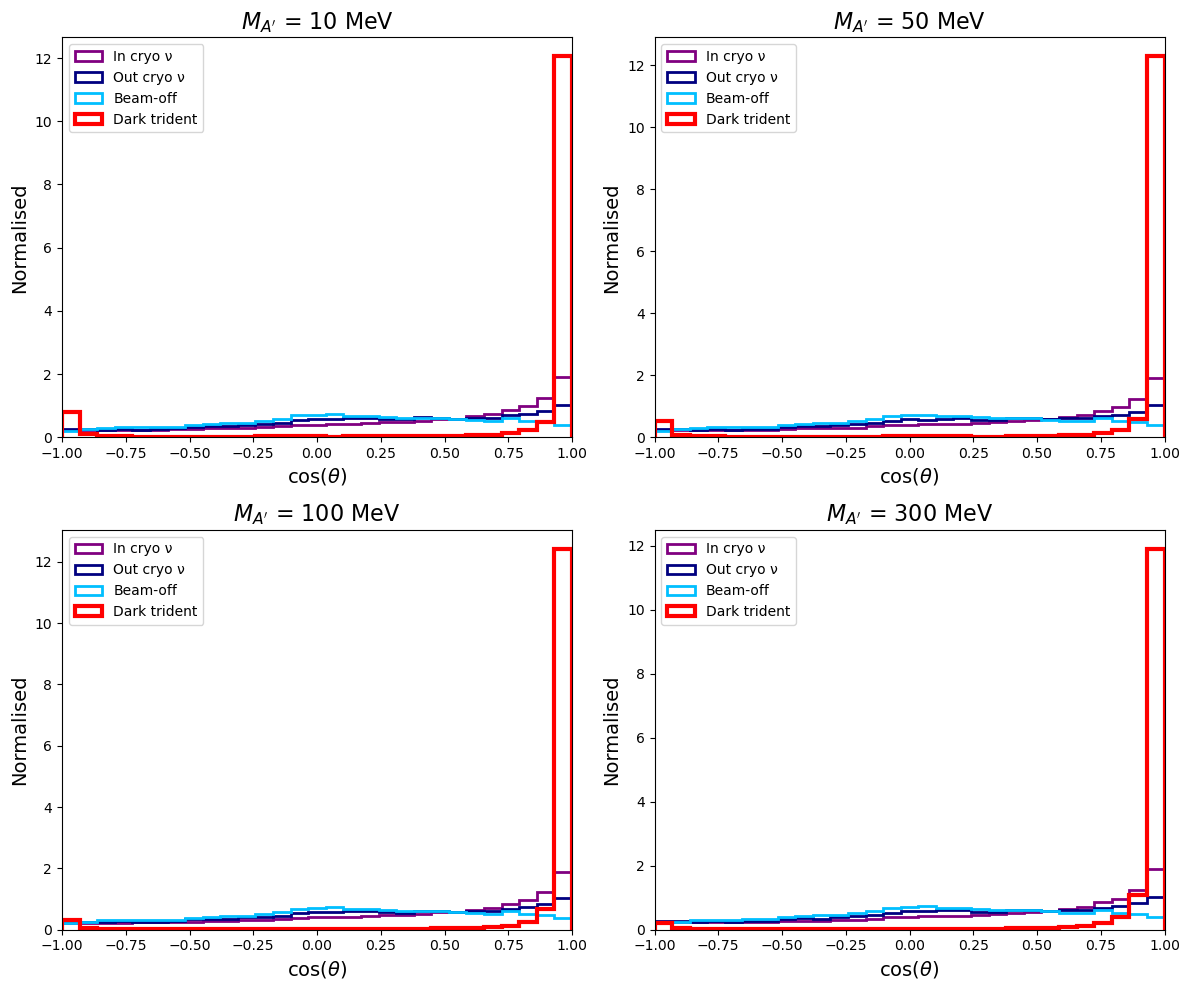

In [16]:
# Pick a few mass points to compare
mass_points = [0.01, 0.05, 0.1, 0.3]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

bins = np.linspace(-1, 1, 30)

for i, mass in enumerate(mass_points):
    ax = axes[i]
    
    # Get signal for this mass (combine pi0 and eta if needed)
    if mass <= 0.01:
        sig_key = f'run1_dt_ratio_0.6_ma_{mass}_pi0_sp'
        df_sig = signal_dfs[sig_key]
    elif mass >= 0.1:
        sig_key = f'run1_dt_ratio_0.6_ma_{mass}_eta_sp'
        df_sig = signal_dfs[sig_key]
    else:
        # Combine pi0 and eta
        df_sig = pd.concat([
            signal_dfs[f'run1_dt_ratio_0.6_ma_{mass}_pi0_sp'],
            signal_dfs[f'run1_dt_ratio_0.6_ma_{mass}_eta_sp']
        ])
    
    # Plot backgrounds (normalised to unit area for shape comparison)
    ax.hist(df_nu['cos_theta'], bins=bins, density=True, histtype='step', 
            lw=2, color='purple', label='In cryo ν')
    ax.hist(df_dirt['cos_theta'], bins=bins, density=True, histtype='step', 
            lw=2, color='navy', label='Out cryo ν')
    ax.hist(df_offbeam['cos_theta'], bins=bins, density=True, histtype='step', 
            lw=2, color='deepskyblue', label='Beam-off')
    
    # Plot signal
    ax.hist(df_sig['cos_theta'], bins=bins, density=True, histtype='step', 
            lw=3, color='red', label='Dark trident')
    
    ax.set_xlabel(r'cos($\theta$)', fontsize=14)
    ax.set_ylabel('Normalised', fontsize=14)
    ax.set_title(f'$M_{{A\'}}$ = {mass*1000:.0f} MeV', fontsize=16)
    ax.legend(fontsize=10)
    ax.set_xlim(-1, 1)

plt.tight_layout()
plt.savefig(plot_dir / 'costheta_distributions_by_mass.png', dpi=300, bbox_inches='tight')
plt.show()

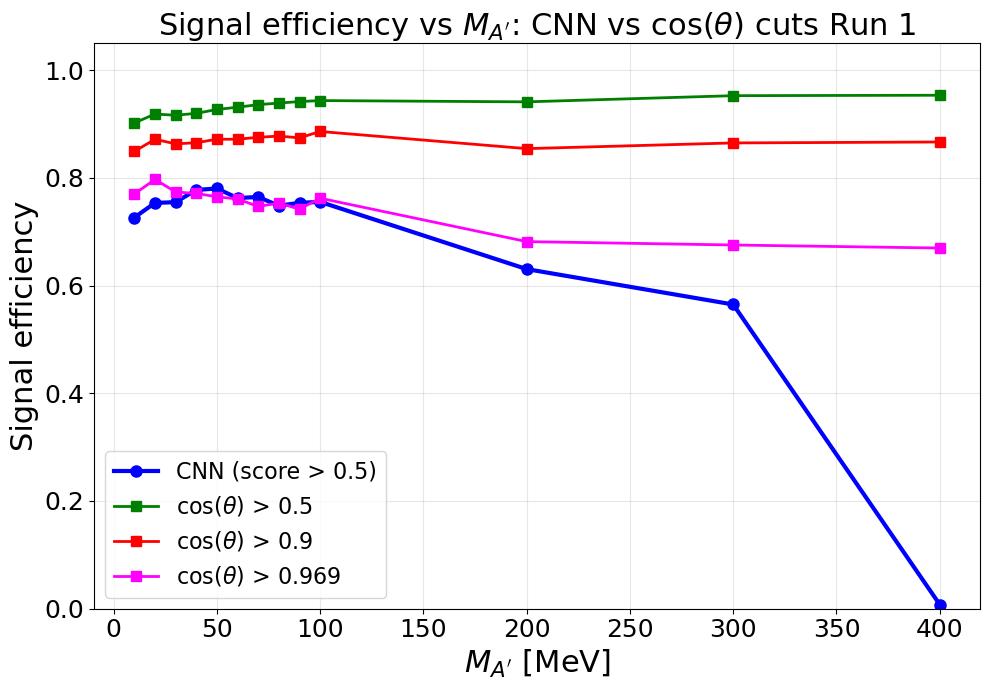

In [23]:
# Signal efficiency vs mass: cos(theta) vs CNN comparison
masses = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.2, 0.3, 0.4]
cos_cuts = [0.5, 0.9, 0.969]

# CNN efficiency (score > 0.5) per massload from scored CSVs
cnn_signal_dir = Path("/home/paul/Msci/dm_sets/run1_signal/")
cnn_efficiencies = []

for mass in masses:
    if mass <= 0.01:
        fname = f"run1_dt_ratio_0.6_ma_{mass}_pi0_larcv_cropped_scores.csv"
    elif mass >= 0.1:
        fname = f"run1_dt_ratio_0.6_ma_{mass}_eta_larcv_cropped_scores.csv"
    else:
        # Combine pi0 and eta
        fname_pi0 = f"run1_dt_ratio_0.6_ma_{mass}_pi0_larcv_cropped_scores.csv"
        fname_eta = f"run1_dt_ratio_0.6_ma_{mass}_eta_larcv_cropped_scores.csv"
        df_pi0 = pd.read_csv(cnn_signal_dir / fname_pi0)
        df_eta = pd.read_csv(cnn_signal_dir / fname_eta)
        df_cnn_sig = pd.concat([df_pi0, df_eta], ignore_index=True)
        df_cnn_sig = df_cnn_sig[df_cnn_sig['signal_score'] >= 0]
        eff = (df_cnn_sig['signal_score'] >= 0.5).mean()
        cnn_efficiencies.append(eff)
        continue
    
    df_cnn_sig = pd.read_csv(cnn_signal_dir / fname)
    df_cnn_sig = df_cnn_sig[df_cnn_sig['signal_score'] >= 0]
    eff = (df_cnn_sig['signal_score'] >= 0.5).mean()
    cnn_efficiencies.append(eff)

# cos(theta) efficiency per mass per cut
costheta_efficiencies = {cut: [] for cut in cos_cuts}

for mass in masses:
    # Get signal for this mass
    if mass <= 0.01:
        sig_key = f'run1_dt_ratio_0.6_ma_{mass}_pi0_sp'
        df_sig = signal_dfs[sig_key]
    elif mass >= 0.1:
        sig_key = f'run1_dt_ratio_0.6_ma_{mass}_eta_sp'
        df_sig = signal_dfs[sig_key]
    else:
        df_sig = pd.concat([
            signal_dfs[f'run1_dt_ratio_0.6_ma_{mass}_pi0_sp'],
            signal_dfs[f'run1_dt_ratio_0.6_ma_{mass}_eta_sp']
        ], ignore_index=True)
    
    for cut in cos_cuts:
        eff = (df_sig['cos_theta'] > cut).mean()
        costheta_efficiencies[cut].append(eff)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))

masses_mev = [m * 1000 for m in masses]

ax.plot(masses_mev, cnn_efficiencies, 'b-o', lw=3, markersize=8, label='CNN (score > 0.5)')

colors_cos = {'0.5': 'green', '0.9': 'red', '0.969': 'magenta'}
for cut in cos_cuts:
    ax.plot(masses_mev, costheta_efficiencies[cut], '-s', lw=2, markersize=7,
            color=colors_cos[str(cut)], label=rf'cos($\theta$) > {cut}')

ax.set_xlabel(r'$M_{A^\prime}$ [MeV]', fontsize=22)
ax.set_ylabel('Signal efficiency', fontsize=22)
ax.set_title(r'Signal efficiency vs $M_{A^\prime}$: CNN vs cos($\theta$) cuts Run 1', fontsize=22)
ax.legend(fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig(plot_dir / 'efficiency_vs_mass_cnn_vs_costheta.png', dpi=300, bbox_inches='tight')
plt.show()

In [19]:
for mass in [0.2, 0.3, 0.4]:
    fname = f"run1_dt_ratio_0.6_ma_{mass}_eta_larcv_cropped_scores.csv"
    df = pd.read_csv(cnn_signal_dir / fname)
    df = df[df['signal_score'] >= 0]
    total = len(df)
    passing = (df['signal_score'] >= 0.5).sum()
    print(f"Mass {mass}: {passing}/{total} pass score > 0.5, eff = {passing/total:.3f}")

Mass 0.2: 3792/6013 pass score > 0.5, eff = 0.631
Mass 0.3: 6968/12334 pass score > 0.5, eff = 0.565
Mass 0.4: 96/12636 pass score > 0.5, eff = 0.008
